In [1]:
import polars as pl
import polars.selectors as cs
from hta.trace_analysis import TraceAnalysis
import pandas as pd
import glob
import os

In [2]:
power_labels = [
    "IBP,",        "ICP,",        "DCP,",      "TCP,",      "CCP,",
    "SHRDP,",      "RFP,",        "INTP,",     "FPUP,",     "DPUP,",
    "INT_MUL24P,", "INT_MUL32P,", "INT_MULP,", "INT_DIVP,", "FP_MULP,",
    "FP_DIVP,",    "FP_SQRTP,",   "FP_LGP,",   "FP_SINP,",  "FP_EXP,",
    "DP_MULP,",    "DP_DIVP,",    "TENSORP,",  "TEXP,",     "SCHEDP,",
    "L2CP,",       "MCP,",        "NOCP,",     "DRAMP,",    "PIPEP,",
    "IDLE_COREP,", "CONSTP",      "STATICP"
]

In [ ]:
df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log", 
        has_header=False, 
        separator="?", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
df

index,benchmark,data
u32,str,str
0,"""bert""","""kernel_name = _ZN2at6native44_…"
1,"""bert""","""kernel_launch_uid = 1 """
2,"""bert""",null
3,"""bert""","""Kernel Average Power Data:"""
4,"""bert""","""kernel_avg_power = 56.8932"""
…,…,…
1876009,"""resnet50-train""","""gpu_tot_avg_power = 95.5163"""
1876010,"""resnet50-train""","""gpu_tot_max_power = 253.477"""
1876011,"""resnet50-train""","""gpu_tot_min_power = 55.4642"""


In [44]:
power_df = (
    (
        df.filter(pl.col("data").str.starts_with("gpu_avg_"))
        .select(
            "index",
            pl.col("data")
            .str.replace("^gpu_avg_", "")
            .str.replace_all(" ", "")
            .str.splitn("=", 2)
            .struct.rename_fields(["label", "value"])
            .struct.with_fields(pl.field("value").cast(float))
            .struct.unnest()
        )
    )
    .join_asof(
        df.filter(pl.col("data").str.starts_with("kernel_name"))
        .select(
            pl.col("index"),
            pl.col("index").rank("dense").over("benchmark").alias("serial"),
            pl.col("benchmark"),
            pl.col("data").str.extract("kernel_name = (.*)").alias("kernel")
        ),
        on="index",
    )
    .drop("index")
    .group_by("benchmark", "serial", "kernel", "label").agg(pl.mean("value"))
    .pivot(on="label", index=["benchmark", "serial", "kernel"])
    .select("benchmark", "serial", "kernel", *power_labels)
    .with_columns(
        pl.col("DRAMP,") + pl.col("MCP,"),
        pl.col("L2CP,") + pl.col("NOCP,"),
    )
    .rename(lambda col: col.replace(",", ""))
    .unpivot(index=["benchmark", "serial", "kernel"], value_name="power_w")
    .group_by("benchmark", "serial", "kernel")
    .agg(pl.sum("power_w"))
    .sort("benchmark", "serial", "kernel")
)
power_df

benchmark,serial,kernel,power_w
str,u32,str,f64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",57.490228
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",57.322012
"""bert""",3,"""_ZN2at6native29vectorized_elem…",56.733263
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",57.496691
"""bert""",5,"""_ZN2at6native29vectorized_elem…",56.42046
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",69.95192
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",84.832087
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",100.542158


In [56]:
df = (
    pl.scan_csv("/proj/threadtune-PG0/amir/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
df

index,benchmark,data
u32,str,str
0,"""bert""","""Skipping setup_environment - a…"
1,"""bert""","""doing: export -n PTX_SIM_USE_P…"
2,"""bert""","""doing: export LD_LIBRARY_PATH=…"
3,"""bert""","""doing: cd /users/zarand1a/acce…"
4,"""bert""","""doing: export OPENCL_CURRENT_T…"
…,…,…
23143917,"""resnet50-train""","""gpgpu_simulation_rate = 230813…"
23143918,"""resnet50-train""","""gpgpu_simulation_rate = 185 (c…"
23143919,"""resnet50-train""","""gpgpu_silicon_slowdown = 61189…"


In [57]:
cycle_df = (
    df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "benchmark",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "benchmark",
    pl.col("index").rank("dense").over("benchmark").alias("serial"),
    "kernel", "cycle",
)

In [58]:
cycle_df

benchmark,serial,kernel,cycle
str,u32,str,i64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",10376
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",8566
"""bert""",3,"""_ZN2at6native29vectorized_elem…",5772
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",10402
"""bert""",5,"""_ZN2at6native29vectorized_elem…",5772
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",23800
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",50736
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",172263


In [59]:
accel_df = (
    power_df.join(cycle_df, on=["benchmark", "serial", "kernel"])
    .filter(pl.col("power_w").is_not_nan())
    .group_by("benchmark")
    .agg(
        power_w=(pl.col("power_w") * pl.col("cycle")).sum() / pl.col("cycle").sum(),
        cycles=pl.col("cycle").sum()
    )
)
accel_df

benchmark,power_w,cycles
str,f64,i64
"""gpt2""",92.793675,5209931
"""bloom""",112.715731,8252003
"""bloom-train""",111.201916,69053879
"""resnet50""",92.827203,5494692
"""gemma""",118.201962,25139094
…,…,…
"""resnet50-train""",98.370075,24016207
"""gemma-train""",167.871848,8792586
"""deit""",91.044472,8096467


In [60]:
df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
)

In [61]:
df

timestamp_ns,total_energy_millijoules,benchmark
i64,i64,str
1364646157625482,59971087531,"""bert"""
1364646257758199,59971092520,"""bert"""
1364646357848963,59971097523,"""bert"""
1364646458912655,59971102673,"""bert"""
1364646559062579,59971107933,"""bert"""
…,…,…
1458527321965226,63909522404,"""resnet50-train"""
1458527422100828,63909529545,"""resnet50-train"""
1458527522249609,63909536871,"""resnet50-train"""


In [62]:
measure_df = (
    df.with_columns(
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
)

In [63]:
measure_df

benchmark,power_w,time_us
str,f64,f64
"""bloom-train""",129.951943,34904.192136
"""gpt2-inference""",38.570944,22697.103064
"""gemma-train""",82.827927,204929.481581
"""deit-train""",68.242799,45746.64186
"""deit-inference""",54.731851,41999.117103
…,…,…
"""gemma-inference""",107.656783,20228.55822
"""bert-inference""",59.101363,10755.061665
"""bloom-inference""",74.344924,15222.401692


In [64]:
comp_df = (
    accel_df.rename({"power_w": "accel_power_W"})
    .with_columns(
        (pl.col("cycles") / 1132).alias("accel_time_us"),
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .drop("cycles")
    .join(
        measure_df.rename({"power_w": "measured_power_W", "time_us": "measured_time_us"}), 
        on="benchmark"
    )
)
comp_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us
str,f64,f64,f64,f64
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064
"""gemma-train""",167.871848,7767.30212,82.827927,204929.481581
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103
…,…,…,…,…
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692


In [65]:
kineto_df = pl.read_json("/proj/threadtune-PG0/amir/kineto_traces/bert-train/device.0.json").select(pl.col("traceEvents").explode().struct.unnest())
kineto_df.filter(pl.col("cat") == "Trace").select("dur") - kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()


dur
f64
631781.294


In [66]:
kineto_df.filter(pl.col("cat") == "Trace").select("dur")

dur
f64
652527.152


In [67]:
kineto_df.filter(pl.col("cat") == "kernel").select("dur").sum()

dur
f64
20745.858


In [68]:
xml_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/sim_run_12.8/bert/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml", 
        separator="\x1f",
        has_header=False, 
        new_columns=["line"],
        quote_char=None
    )
    .filter(pl.col("line").str.contains('name="constant_power"'))
    .select(
        pl.col("line")
        .str.extract(r'value="([\d\.]+)"', 1)
        .cast(pl.Float64)
    )
    .collect()
)
constant_power = xml_df.item()
print(f"Constant Power: {constant_power}")

Constant Power: 32.32522272


In [69]:
kineto_root = "/proj/threadtune-PG0/amir/kineto_traces/*"
xml_base_path = "/proj/threadtune-PG0/amir/sim_run_12.8"

results = []

for trace_dir in glob.glob(kineto_root):
    full_benchmark_name = os.path.basename(trace_dir)
    
    if "-inference" in full_benchmark_name:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name.replace("-inference", "")
    else:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name

    print(f"Processing: {full_benchmark_name} (Cleaned: {benchmark_name})")

    json_path = os.path.join(trace_dir, "device.0.json")
    
    if not os.path.exists(json_path):
        print(f"  Skipping: {json_path} not found.")
        continue

    try:
        kineto_df = (
            pl.read_json(json_path)
            .select(pl.col("traceEvents").explode().struct.unnest())
        )

        total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
        total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

        if total_trace_dur is None: total_trace_dur = 0
        if total_kernel_dur is None: total_kernel_dur = 0
        
        idle_time_us = total_trace_dur - total_kernel_dur

    except Exception as e:
        print(f"  Error reading Kineto trace: {e}")
        continue

    xml_path = f"{xml_base_path}/{xml_model_name}/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml"
    
    if not os.path.exists(xml_path):
        print(f"  Warning: XML not found at {xml_path}")
        constant_power = None
        idle_energy = None
    else:
        try:
            xml_df = (
                pl.scan_csv(
                    xml_path, 
                    separator="\x1f", 
                    has_header=False, 
                    new_columns=["line"],
                    quote_char=None
                )
                .filter(pl.col("line").str.contains('name="constant_power"'))
                .select(
                    pl.col("line")
                    .str.extract(r'value="([\d\.]+)"', 1)
                    .cast(pl.Float64)
                )
                .collect()
            )
            
            if xml_df.height > 0:
                constant_power = xml_df.item()
                
                idle_energy = idle_time_us * constant_power
            else:
                constant_power = None
                idle_energy = None
                
        except Exception as e:
            print(f"  Error parsing XML: {e}")
            constant_power = None
            idle_energy = None

    results.append({
        "benchmark": benchmark_name,
        "idle_time_us": idle_time_us,
        "constant_power_W": constant_power,
        "idle_energy_uJ": idle_energy
    })

idle_df = pl.DataFrame(results)

Processing: deit-train (Cleaned: deit-train)
Processing: gpt2-inference (Cleaned: gpt2-inference)
Processing: bloom-train (Cleaned: bloom-train)
Processing: resnet50-train (Cleaned: resnet50-train)
Processing: gpt2-train (Cleaned: gpt2-train)
Processing: resnet50-inference (Cleaned: resnet50-inference)
Processing: bert-inference (Cleaned: bert-inference)
Processing: deit-inference (Cleaned: deit-inference)
Processing: bloom-inference (Cleaned: bloom-inference)
Processing: bert-train (Cleaned: bert-train)
Processing: gemma-inference (Cleaned: gemma-inference)


In [70]:
idle_df

benchmark,idle_time_us,constant_power_W,idle_energy_uJ
str,f64,f64,f64
"""deit-train""",653582.668,32.325223,2.1127e7
"""gpt2-inference""",461579.941,32.325223,1.4921e7
"""bloom-train""",406342.152,32.325223,1.3135e7
"""resnet50-train""",690036.105,32.325223,2.2306e7
"""gpt2-train""",557731.427,32.325223,1.8029e7
…,…,…,…
"""bert-inference""",312991.064,32.325223,1.0118e7
"""deit-inference""",319870.91,32.325223,1.0340e7
"""bloom-inference""",553572.69,32.325223,1.7894e7


In [71]:
main_df = comp_df.join(
    idle_df.select("benchmark", pl.col("constant_power_W").alias("idle_power_W"), "idle_time_us"),
    on="benchmark"
)

In [72]:
main_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us,idle_power_W,idle_time_us
str,f64,f64,f64,f64,f64,f64
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136,32.325223,406342.152
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064,32.325223,461579.941
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186,32.325223,653582.668
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103,32.325223,319870.91
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234,32.325223,557731.427
…,…,…,…,…,…,…
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822,32.325223,492388.531
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665,32.325223,312991.064
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692,32.325223,553572.69


In [73]:
import polars as pl

# 1. Add the necessary calculated columns to create 'master_df'
master_df = main_df.with_columns([
    # Expansion Factor: How much longer is real execution compared to simulation active time?
    (pl.col("measured_time_us") / pl.col("accel_time_us")).alias("time_expansion_factor"),
    
    # Duty Cycle: What percentage of the total wall-clock time was the GPU actually active?
    (pl.col("accel_time_us") / pl.col("measured_time_us")).alias("duty_cycle_pct")
])

# 2. Select, Format, and Rename columns for the LaTeX table
latex_df = master_df.select(
    pl.col("benchmark").str.replace("_", "-").alias("Model"),
    (pl.col("accel_time_us") / 1000).cast(pl.Int64).alias("Sim Time (ms)"),
    (pl.col("measured_time_us") / 1000).cast(pl.Int64).alias("Real Time (ms)"),
    (pl.col("time_expansion_factor")).round(1).alias("Speedup Factor"),
    (pl.col("duty_cycle_pct") * 100).round(1).alias("GPU Duty Cycle (%)")
)

# 3. Generate the LaTeX code
# Note: Requires pandas installed for the to_latex() method
print(latex_df.to_pandas().to_latex(index=False))

\begin{tabular}{lrrrr}
\toprule
Model & Sim Time (ms) & Real Time (ms) & Speedup Factor & GPU Duty Cycle (%) \\
\midrule
bloom-train & 61 & 34 & 0.600000 & 174.800000 \\
gpt2-inference & 4 & 22 & 4.900000 & 20.300000 \\
deit-train & 15 & 45 & 2.900000 & 34.100000 \\
deit-inference & 7 & 41 & 5.900000 & 17.000000 \\
gpt2-train & 43 & 52 & 1.200000 & 81.700000 \\
resnet50-train & 21 & 41 & 1.900000 & 51.500000 \\
gemma-inference & 22 & 20 & 0.900000 & 109.800000 \\
bert-inference & 2 & 10 & 4.400000 & 22.800000 \\
bloom-inference & 7 & 15 & 2.100000 & 47.900000 \\
resnet50-inference & 4 & 41 & 8.500000 & 11.800000 \\
bert-train & 35 & 53 & 1.500000 & 66.200000 \\
\bottomrule
\end{tabular}



In [74]:
correct_df = (
    main_df.filter(pl.col("accel_time_us") < pl.col("measured_time_us"))
    .with_columns(
        corrected_power_W = (
            pl.col("accel_power_W") * pl.col("accel_time_us") + 
            (pl.col("measured_time_us") - pl.col("accel_time_us")) * pl.col("idle_power_W")
        ) / (
            pl.col("measured_time_us")
        )
    )
)

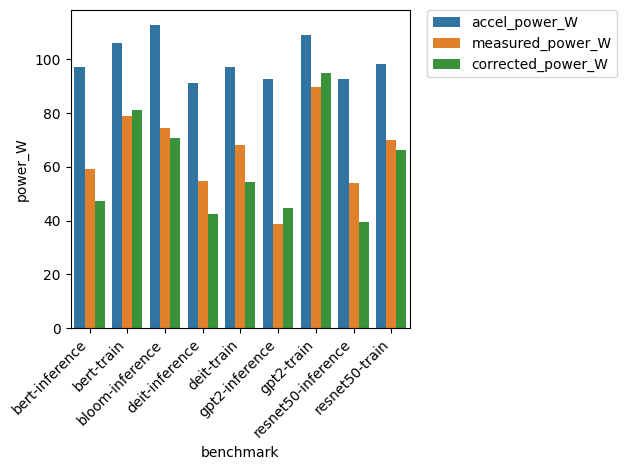

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .unpivot(index="benchmark", value_name="power_W", variable_name="type"),
    x="benchmark", y="power_W", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
# plt.savefig("power.png")

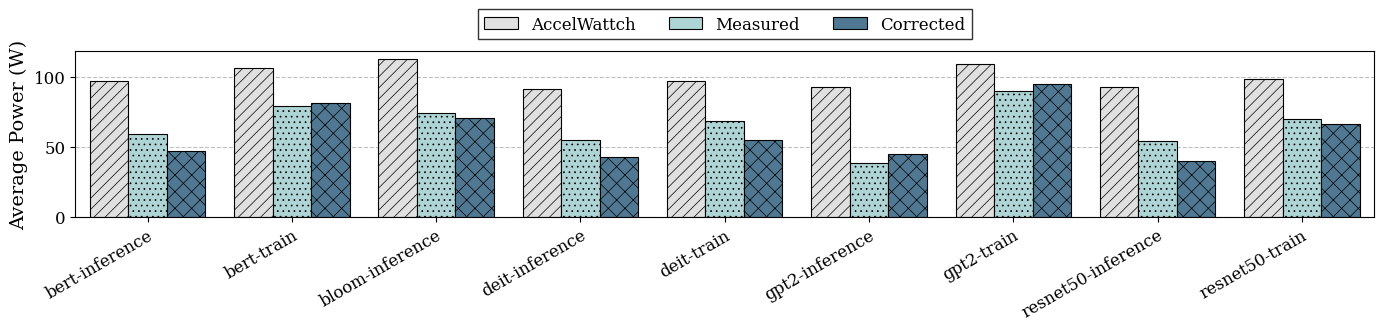

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# --- 1. WIDE FIGURE CONFIGURATION ---
# Width of ~7 inches is standard for 2-column papers (spanning both columns).
# We use a slightly larger size (14x3.5) so it scales down crisply.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 3.5), # Wide aspect ratio
    "hatch.linewidth": 0.5       # Thinner hatch lines for elegance
})

# --- 2. DATA PREPARATION ---
plot_df = (
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .rename({
        "accel_power_W": "AccelWattch",
        "measured_power_W": "Measured",
        "corrected_power_W": "Corrected"
    })
    .unpivot(index="benchmark", value_name="power_W", variable_name="Type")
    .to_pandas()
)

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

# Use a grayscale/muted palette which prints well in black & white papers
# Colors: Light Grey, Light Blue, Dark Blue/Slate
colors = ["#e0e0e0", "#a8dadc", "#457b9d"] 

bar = sns.barplot(
    data=plot_df, 
    x="benchmark", 
    y="power_W", 
    hue="Type", 
    ax=ax, 
    palette=colors,
    edgecolor="black", 
    linewidth=0.8,
    width=0.8
)

# --- 4. APPLY HATCHING (3 Patterns) ---
# Since we have 3 bars per group, we need 3 distinct patterns
# 1. Accelerator: Diagonal lines (//)
# 2. Measured: Dots (..)
# 3. Corrected: Crosshatch (xx) or darker diagonal (\\)
hatches = ['///', '...', 'xx'] 

for i, container in enumerate(ax.containers):
    # Loop through each bar in the container
    for patch in container:
        # Set pattern based on the container index (0, 1, or 2)
        patch.set_hatch(hatches[i % len(hatches)])

# --- 5. LAYOUT & STYLING ---
ax.grid(which='major', axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("", fontsize=1)
ax.set_ylabel("Average Power (W)", fontsize=14)

# Rotate x-ticks slightly for readability
plt.xticks(rotation=30, ha='right', rotation_mode="anchor")

# Legend: Centered above the plot, horizontal
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=3, # 3 columns for 3 items
    frameon=True, 
    edgecolor="black",
    fancybox=False
)

plt.tight_layout()

# Save
plt.savefig("power.pdf", dpi=300, bbox_inches='tight')
plt.show()

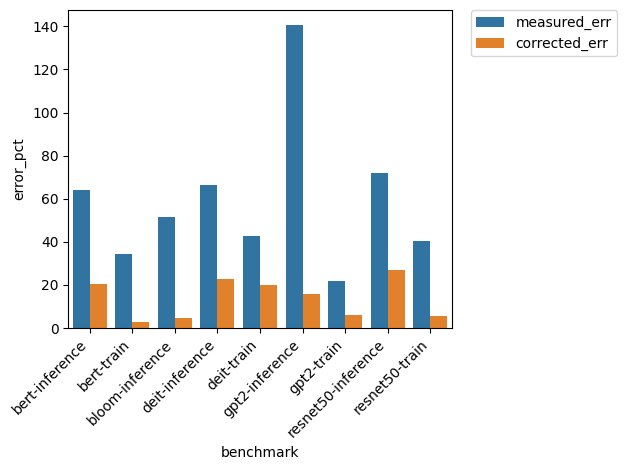

In [76]:
sns.barplot(
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .select(
        "benchmark",
        measured_err = (pl.col("accel_power_W")/pl.col("measured_power_W") - 1) * 100,
        corrected_err = abs(pl.col("corrected_power_W")/pl.col("measured_power_W") - 1) * 100,
    )
    .unpivot(index="benchmark", value_name="error_pct", variable_name="type"),
    x="benchmark", y="error_pct", hue="type"
)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) 
plt.tight_layout()
plt.savefig("error.png")

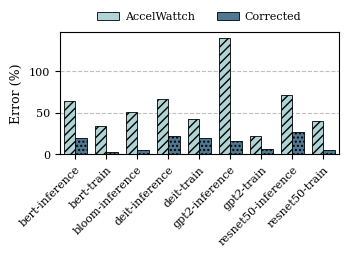

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

# --- 1. SINGLE-COLUMN STYLE CONFIGURATION ---
# A typical single column is ~3.3 to 3.5 inches wide.
# We make the height about 2.5 inches for a good aspect ratio.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    # Reduce font sizes for the smaller plot
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 2.5), # <--- KEY CHANGE: Width ~3.4 inches
    "figure.autolayout": True # Helps with tight layouts automatically
})

# --- 2. DATA PREPARATION (Same as before) ---
# Assuming 'correct_df' is your existing Polars DataFrame
plot_df = (
    correct_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .select(
        pl.col("benchmark"),
        AccelWattch = (pl.col("accel_power_W")/pl.col("measured_power_W") - 1) * 100,
        Corrected = (pl.col("corrected_power_W")/pl.col("measured_power_W") - 1).abs() * 100,
    )
    .unpivot(index="benchmark", value_name="error_pct", variable_name="Type")
    .to_pandas()
)

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

colors = ["#a8dadc", "#457b9d"]

# Create the bar plot with slightly thinner bars and lines for the smaller scale
bar = sns.barplot(
    data=plot_df, 
    x="benchmark", 
    y="error_pct", 
    hue="Type", 
    ax=ax, 
    palette=colors,
    edgecolor="black", 
    linewidth=0.6, # Slightly thinner line
    width=0.75
)

# --- 4. APPLY HATCHING ---
# Using slightly denser patterns for smaller bars can look better
hatches = ['////', '....'] 
for i, container in enumerate(ax.containers):
    for patch in container:
        patch.set_hatch(hatches[i % len(hatches)])

# --- 5. FINE TUNING LAYOUT ---
ax.grid(which='major', axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("", fontsize=1) # Basically hide x-label space
ax.set_ylabel("Error (%)")

# Rotate x-ticks more sharply to fit in the narrow space
plt.xticks(rotation=45, ha='right', rotation_mode="anchor")

# Place legend inside the plot or just above to save vertical space.
# (0.5, 1.05) puts it just above the top border.
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False, # Removing frame saves visual clutter in small plots
    borderpad=0.2,
    handletextpad=0.5
)

# Important for single-column to remove excess whitespace
plt.tight_layout(pad=0.5)

# Save with high DPI
# plt.savefig("error.pdf", dpi=300)
plt.show()

In [106]:
FREQ_MHZ = 1132 

final_df = (
    comp_df.join(idle_df, on="benchmark", how="inner")
    .with_columns([
        # Time (us) = Cycles / (Cycles/us)
        (pl.col("cycles") / FREQ_MHZ).alias("active_time_us"),
    ])
    .with_columns([
        # Energy (uJ) = Power (W) * Time (us)
        # (Watts * Microseconds = Microjoules)
        (pl.col("accel_power_W") * pl.col("active_time_us")).alias("active_energy_uJ")
    ])
    
    .select([
        pl.col("benchmark"),
        pl.col("measure_power_W"),
        pl.col("accel_power_W").alias("old_active_power_W"),
        
        # Corrected Power = (Active Energy + Idle Energy) / (Active Time + Idle Time)
        (
            (pl.col("active_energy_uJ") + pl.col("idle_energy_uJ")) / 
            (pl.col("active_time_us") + pl.col("idle_time_us"))
        ).alias("corrected_power_W")
    ])
)

final_df

ColumnNotFoundError: unable to find column "cycles"; valid columns: ["benchmark", "accel_power_W", "accel_time_us", "measured_power_W", "measured_time_us", "idle_time_us", "constant_power_W", "idle_energy_uJ"]

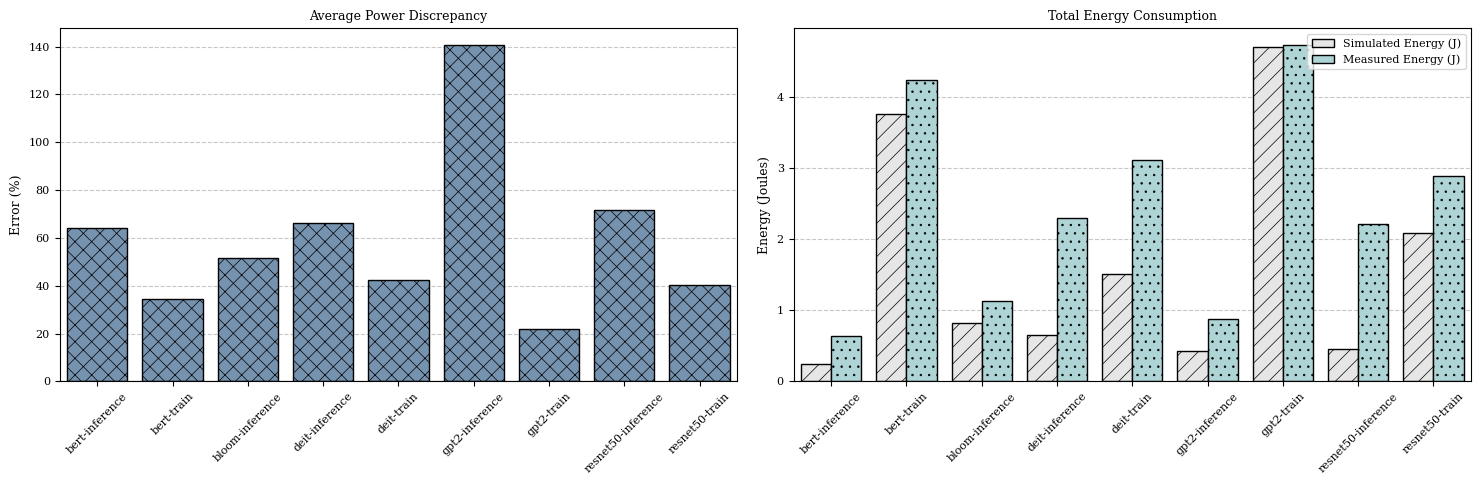

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import polars as pl # Assuming polars is used based on your snippet

# --- 1. Data Preparation (Unchanged) ---
# Assuming 'correct_df' is already defined in your environment
analysis_df = (
    correct_df
    .with_columns([
        (pl.col("accel_power_W") * pl.col("accel_time_us") / 1e6).alias("Simulated Energy (J)"),
        (pl.col("measured_power_W") * pl.col("measured_time_us") / 1e6).alias("Measured Energy (J)"),
        ((pl.col("accel_power_W") - pl.col("measured_power_W")) / pl.col("measured_power_W") * 100).alias("Power Discrepancy (%)")
    ])
    .sort("benchmark")
)

pdf = analysis_df.to_pandas()

# --- 2. Plotting Setup (Style Configuration) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Set global font to Serif to match the academic paper style in the images
plt.rcParams.update({
    'font.size': 12, 
    'font.family': 'serif',
    'hatch.linewidth': 0.5  # Controls thickness of the hatch lines
})

# Define Custom Pastel Colors similar to the images
# Greyish for "AccelWattch/Simulated", Teal for "Measured", Blue for "Discrepancy"
color_sim = "#e6e6e6"   # Light grey (Pastel)
color_meas = "#a8dadc"  # Pastel Teal
color_err = "#6c92b8"   # Muted Blue (similar to the 'Corrected' bar in image 1)

# --- 3. Left Plot: Average Power Discrepancy ---
sns.barplot(
    data=pdf,
    x="benchmark",
    y="Power Discrepancy (%)",
    ax=axes[0],
    color=color_err,
    edgecolor="black",
    linewidth=1
)

# Apply Cross-hatch pattern ('xx') to the Error bars (Style 3 from your image)
for container in axes[0].containers:
    for bar in container:
        bar.set_hatch('xx') 

axes[0].set_title("Average Power Discrepancy")
axes[0].set_ylabel("Error (%)")
axes[0].set_xlabel("")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
# Dotted grid lines behind
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- 4. Right Plot: Energy Consumed (Simulated vs Measured) ---
energy_pdf = pdf[["benchmark", "Simulated Energy (J)", "Measured Energy (J)"]].melt(
    id_vars="benchmark", 
    var_name="Type", 
    value_name="Energy (J)"
)

sns.barplot(
    data=energy_pdf,
    x="benchmark",
    y="Energy (J)",
    hue="Type",
    ax=axes[1],
    # We set a base palette, but we will override hatches manually below
    palette=[color_sim, color_meas], 
    edgecolor="black",
    linewidth=1
)

# Customizing Hatches for the Grouped Bar Chart
# container[0] is the first hue (Simulated), container[1] is the second hue (Measured)
hatch_patterns = ['//', '..'] # Diagonal lines for Sim, Dots for Measured

for i, container in enumerate(axes[1].containers):
    # Apply the specific hatch to this entire group
    for bar in container:
        bar.set_hatch(hatch_patterns[i])

axes[1].set_title("Total Energy Consumption")
axes[1].set_ylabel("Energy (Joules)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_axisbelow(True)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Clean up legend to show the patterns
axes[1].legend(title=None, loc='upper right')

# --- 5. Final Layout Adjustments ---
plt.tight_layout()
plt.savefig("styled_power_energy_plot.png", dpi=300, bbox_inches='tight')
plt.show()

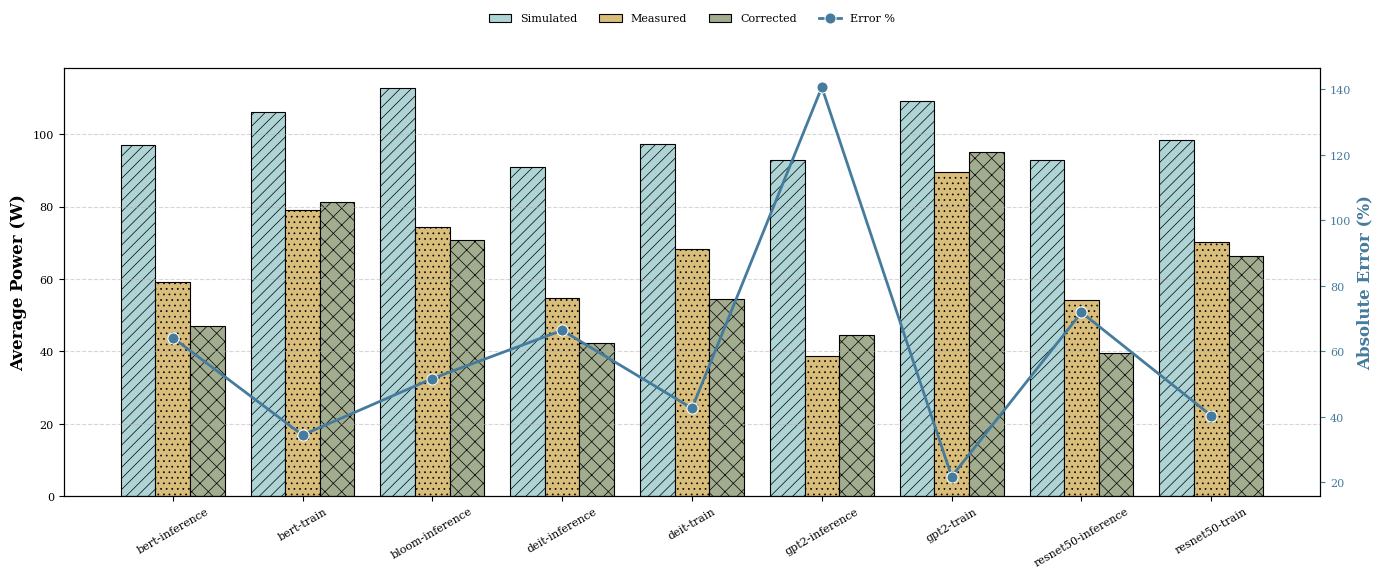

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

# --- 1. Data Preparation ---
# We assume 'correct_df' is available from the previous steps.
# We create two dataframes: one for the bars (Power) and one for the line (Error).

# Prepare Bar Data (Long Format)
bar_data = (
    correct_df
    .select(["benchmark", "accel_power_W", "measured_power_W", "corrected_power_W"])
    .rename({
        "accel_power_W": "Simulated", 
        "measured_power_W": "Measured", 
        "corrected_power_W": "Corrected"
    })
    .unpivot(index="benchmark", variable_name="Type", value_name="Power (W)")
    .sort("benchmark")
    .to_pandas()
)

# Prepare Line Data (Error %)
line_data = (
    correct_df
    .with_columns(
        ((pl.col("accel_power_W") - pl.col("measured_power_W")) / pl.col("measured_power_W") * 100).abs().alias("Error (%)")
    )
    .select(["benchmark", "Error (%)"])
    .sort("benchmark")
    .to_pandas()
)

# --- 2. Style Configuration ---
# Setting the font to serif to match the academic style of the screenshot
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

# Pastel Color Palette (Approximate to screenshot)
# Blue (Sim), Beige/Gold (Measured), Green (Corrected)
palette = ["#a8dadc", "#e9c46a", "#a3b18a"] 

# Hatch Patterns (The "Dots and Lines" for the bars)
# // = Diagonal Lines, .. = Dots, xx = Crosshatch
hatches = ['///', '...', 'xx']

# --- 3. Plotting ---
fig, ax1 = plt.subplots(figsize=(14, 6))

# A. The Bar Chart
bar_plot = sns.barplot(
    data=bar_data,
    x="benchmark",
    y="Power (W)",
    hue="Type",
    ax=ax1,
    palette=palette,
    edgecolor="black",
    linewidth=0.8
)

# Apply Hatching to Bars
# Loop through the containers (groups of bars) and assign hatches cyclically
for i, container in enumerate(ax1.containers):
    for patch in container:
        patch.set_hatch(hatches[i % len(hatches)])

# B. The Line Plot ("Add dots and line")
# Create a secondary y-axis for the error percentage
ax2 = ax1.twinx()
sns.lineplot(
    data=line_data,
    x="benchmark",
    y="Error (%)",
    ax=ax2,
    color="#457b9d",  # Darker blue for contrast
    marker='o',       # The "Dot"
    markersize=8,
    linewidth=2,      # The "Line"
    label="Error %",
    linestyle='-'
)

# --- 4. Final Polish ---
# Axis Labels
ax1.set_xlabel("")
ax1.set_ylabel("Average Power (W)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Absolute Error (%)", fontsize=12, fontweight='bold', color="#457b9d")

# Formatting Ticks
ax1.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', colors="#457b9d")

# Legend Handling
# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines + lines2, 
    labels + labels2, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=4, 
    frameon=False
)
ax2.legend_.remove() # Remove the duplicate legend from the second axis

# Grid is usually off for the secondary axis to avoid clutter
ax2.grid(False)

plt.tight_layout()
plt.savefig("styled_power_error_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [109]:
# Select and rename columns for a clean report table
display_table = (
    analysis_df.select([
        pl.col("benchmark").alias("Benchmark"),
        pl.col("accel_power_W").round(2).alias("Sim Power (W)"),
        pl.col("measured_power_W").round(2).alias("Trace Power (W)"),
        pl.col("Power Discrepancy (%)").round(2).alias("Power Error (%)"),
        pl.col("Simulated Energy (J)").round(2),
        pl.col("Measured Energy (J)").round(2)
    ])
)

display_table

# # Optional: Export to LaTeX or CSV
# print(display_table.to_pandas().to_latex(index=False))

Benchmark,Sim Power (W),Trace Power (W),Power Error (%),Simulated Energy (J),Measured Energy (J)
str,f64,f64,f64,f64,f64
"""bert-inference""",96.99,59.1,64.11,0.24,0.64
"""bert-train""",106.19,79.03,34.36,3.77,4.24
"""bloom-inference""",112.72,74.34,51.61,0.82,1.13
"""deit-inference""",91.04,54.73,66.35,0.65,2.3
"""deit-train""",97.27,68.24,42.53,1.52,3.12
"""gpt2-inference""",92.79,38.57,140.58,0.43,0.88
"""gpt2-train""",109.12,89.67,21.69,4.71,4.74
"""resnet50-inference""",92.83,54.03,71.8,0.45,2.22
"""resnet50-train""",98.37,70.12,40.28,2.09,2.89


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


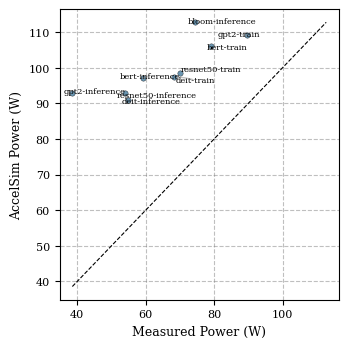

In [110]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text  # Key library for spacing labels

# --- 1. SINGLE-COLUMN STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 3.4), 
    "figure.autolayout": True
})

# --- 2. DATA PREPARATION ---
# Extract data to lists/numpy arrays for easier handling in the loop
# (Polars columns to lists ensures compatibility)
x_vals = display_table["Trace Power (W)"].to_list()
y_vals = display_table["Sim Power (W)"].to_list()
names = display_table["Benchmark"].to_list()

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

primary_color = "#457b9d" 

# Create the scatter plot
# Legend is set to False here
sns.scatterplot(
    x=x_vals, 
    y=y_vals, 
    ax=ax,
    color=primary_color,
    alpha=0.8,              # Slightly higher opacity since there is no legend to identify them
    edgecolor="black",     
    linewidth=0.3, 
    s=15,                   # Slightly larger to anchor the text
    legend=False,           # EXPLICITLY REMOVE LEGEND
    zorder=3
)

# --- 4. LABELING (The "Spaced Apart" Logic) ---
texts = []
for x, y, s in zip(x_vals, y_vals, names):
    # Create the text object, but don't fix its position yet
    texts.append(ax.text(x, y, s, fontsize=6))

# automatically adjust positions to avoid overlap
adjust_text(
    texts,
    ax=ax,
    only_move={'points':'xy', 'text':'xy', 'objects':'xy'},
    force_text=(7, 8),  
    force_points=(5, 8),
    force_objects=(5, 8),
    expand_points=(15, 15), 
    expand_text=(12, 12),
    expand_objects=(12, 12),
    lim=100000,
    arrowprops=dict(
        arrowstyle='-', 
        color='gray', 
        alpha=0.5, 
        lw=1.0,
        shrinkB=5,
        connectionstyle="arc3,rad=0.1" 
    )
)

# --- 5. REFERENCE LINE (y=x) ---
max_val = max(max(x_vals), max(y_vals))
min_val = min(min(x_vals), min(y_vals))

ax.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='black', 
    linestyle='--', 
    linewidth=0.8, 
    label='Ideal (y=x)', # Label technically exists but we aren't showing the legend
    zorder=2
)

# --- 6. FINE TUNING LAYOUT ---
ax.grid(which='major', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Updated labels to match column headers (W instead of microseconds)
ax.set_xlabel("Measured Power (W)") 
ax.set_ylabel("AccelSim Power (W)")

# Remove excess whitespace
plt.tight_layout(pad=0.5)

plt.savefig("accel_vs_trace_power_labeled.pdf", dpi=300)
plt.show()

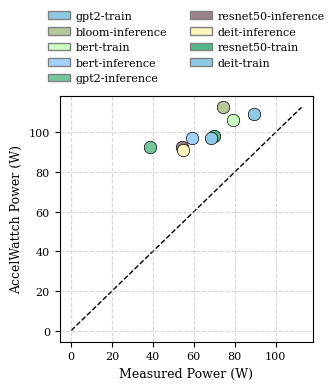

In [111]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Required for the rectangular legend
import seaborn as sns
import numpy as np


# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 3.95), 
    "figure.autolayout": True
})

# --- 2. PALETTE SETUP (Matching your Screenshot) ---
# Custom pastel hex codes extracted roughly from your image
pastel_palette = [
    "#8ecae6", # Light Blue
    "#b5c99a", # Olive/Gold
    "#caffbf", # Mint
    "#a2d2ff", # Sky Blue
    "#74c69d", # Green
    "#9d8189", # Muted Purple
    "#fcf6bd", # Cream/Beige
    "#52b788"  # Darker Green
]

# Map each benchmark to a specific style
unique_benchmarks = display_table["Benchmark"].unique().to_list()
style_map = {}

for i, bench in enumerate(unique_benchmarks):
    # Cycle through colors/hatches if you have more data than defined colors
    color = pastel_palette[i % len(pastel_palette)]
    hatch = hatch_patterns[i % len(hatch_patterns)]
    style_map[bench] = {'color': color}

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

# We plot in a loop to ensure the correct colors map to the points
for bench in unique_benchmarks:
    subset = display_table.filter(pl.col("Benchmark") == bench)
    
    ax.scatter(
        subset["Trace Power (W)"], 
        subset["Sim Power (W)"], 
        color=style_map[bench]['color'],
        edgecolor='black',
        linewidth=0.5,
        s=80, # Points need to be slightly larger to show the pastel color clearly
        zorder=3
    )

# --- 4. CREATING THE CUSTOM LEGEND ---
# This creates the rectangular boxes with patterns seen in your image
legend_handles = []
for bench in unique_benchmarks:
    patch = mpatches.Patch(
        facecolor=style_map[bench]['color'],
        edgecolor='gray',        # Grey borders for the legend box (softer than black)
        label=bench
    )
    legend_handles.append(patch)

# Add reference line
max_val = max(display_table["Sim Power (W)"].max(), display_table["Trace Power (W)"].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1, zorder=1, label="Ideal")

# Configure the Legend Position (Top Center, Horizontal)
# ax.legend(
#     handles=legend_handles,
#     loc='lower center', 
#     bbox_to_anchor=(0.5, 1.05), # Push above the plot
#     ncol=3,                     # Spread horizontally (adjust based on count)
#     frameon=False,              # No box around the legend group
#     borderaxespad=0,
#     handletextpad=0.5,
#     columnspacing=1.5
# )
ax.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False,
    borderpad=0.2,
    handletextpad=0.5
)

# --- 5. LAYOUT ---
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel("Measured Power (W)")
ax.set_ylabel("AccelWattch Power (W)")

plt.savefig("pastel_legend_plot.pdf", dpi=300)
plt.show()

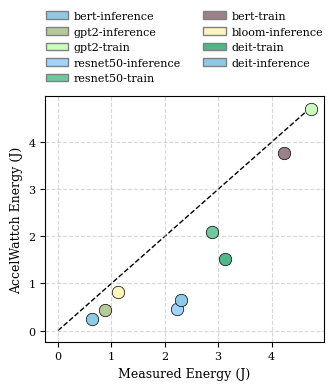

In [112]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Required for the rectangular legend
import seaborn as sns
import numpy as np


# --- 1. STYLE CONFIGURATION ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 3.95), 
    "figure.autolayout": True
})

# --- 2. PALETTE SETUP (Matching your Screenshot) ---
# Custom pastel hex codes extracted roughly from your image
pastel_palette = [
    "#8ecae6", # Light Blue
    "#b5c99a", # Olive/Gold
    "#caffbf", # Mint
    "#a2d2ff", # Sky Blue
    "#74c69d", # Green
    "#9d8189", # Muted Purple
    "#fcf6bd", # Cream/Beige
    "#52b788"  # Darker Green
]

# Map each benchmark to a specific style
unique_benchmarks = display_table["Benchmark"].unique().to_list()
style_map = {}

for i, bench in enumerate(unique_benchmarks):
    # Cycle through colors/hatches if you have more data than defined colors
    color = pastel_palette[i % len(pastel_palette)]
    hatch = hatch_patterns[i % len(hatch_patterns)]
    style_map[bench] = {'color': color}

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

# We plot in a loop to ensure the correct colors map to the points
for bench in unique_benchmarks:
    subset = display_table.filter(pl.col("Benchmark") == bench)
    
    ax.scatter(
        subset["Measured Energy (J)"], 	
        subset["Simulated Energy (J)"], 
        color=style_map[bench]['color'],
        edgecolor='black',
        linewidth=0.5,
        s=80, # Points need to be slightly larger to show the pastel color clearly
        zorder=3
    )

# --- 4. CREATING THE CUSTOM LEGEND ---
# This creates the rectangular boxes with patterns seen in your image
legend_handles = []
for bench in unique_benchmarks:
    patch = mpatches.Patch(
        facecolor=style_map[bench]['color'],
        edgecolor='gray',        # Grey borders for the legend box (softer than black)
        label=bench
    )
    legend_handles.append(patch)

# Add reference line
max_val = max(display_table["Simulated Energy (J)"].max(), display_table["Measured Energy (J)"].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1, zorder=1, label="Ideal")

# Configure the Legend Position (Top Center, Horizontal)
# ax.legend(
#     handles=legend_handles,
#     loc='lower center', 
#     bbox_to_anchor=(0.5, 1.05), # Push above the plot
#     ncol=3,                     # Spread horizontally (adjust based on count)
#     frameon=False,              # No box around the legend group
#     borderaxespad=0,
#     handletextpad=0.5,
#     columnspacing=1.5
# )
ax.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False,
    borderpad=0.2,
    handletextpad=0.5
)

# --- 5. LAYOUT ---
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel("Measured Energy (J)")
ax.set_ylabel("AccelWattch Energy (J)")

plt.savefig("pastel_legend_plot.pdf", dpi=300)
plt.show()

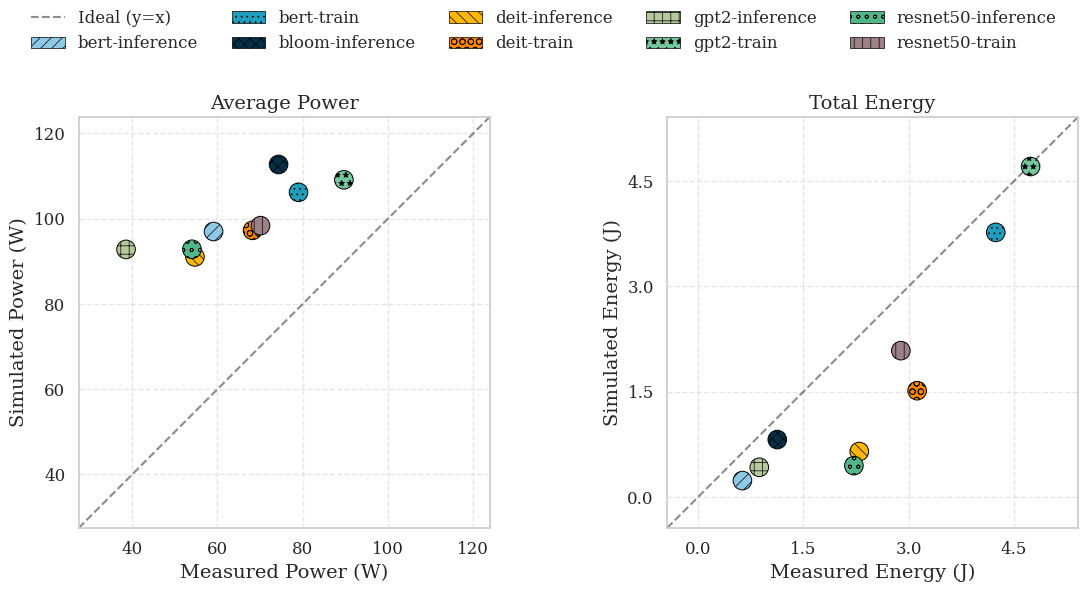

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# --- 1. SETUP & STYLING ---
# Using seaborn style as a base for nicer grid defaults
sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.5})

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 3.5), # Wide aspect ratio
    "hatch.linewidth": 0.5       # Thinner hatch lines for elegance
})

plot_data = (
    correct_df
    .with_columns([
        (pl.col("accel_power_W") * pl.col("accel_time_us") / 1e6).alias("Simulated Energy (J)"),
        (pl.col("measured_power_W") * pl.col("measured_time_us") / 1e6).alias("Measured Energy (J)")
    ])
    .sort("benchmark")
    .to_pandas()
)

benchmarks = plot_data["benchmark"].unique()

# --- 3. COLOR & HATCH MAPPING ---
pastel_palette = [
    "#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500", 
    "#b5c99a", "#74c69d", "#52b788", "#9d8189", "#e29578"
]
hatch_patterns = ['///', '...', 'xxx', '\\\\\\', 'OO', '++', '**', 'oo', '||', '--']

style_map = {}
for i, bench in enumerate(benchmarks):
    style_map[bench] = {
        'color': pastel_palette[i % len(pastel_palette)],
        'hatch': hatch_patterns[i % len(hatch_patterns)]
    }

# --- 4. PLOTTING HELPERS ---

def setup_square_axis(ax, x_data, y_data):
    """
    Calculates unified limits for X and Y to ensure a square grid 
    and adds padding so points aren't cut off.
    """
    all_data = np.concatenate([x_data, y_data])
    d_min, d_max = all_data.min(), all_data.max()
    data_range = d_max - d_min
    
    # Add 15% padding based on the range of data
    padding = data_range * 0.15
    # Handle edge case of single point/zero range
    if padding == 0: padding = d_max * 0.1 if d_max != 0 else 1.0

    limit_min = d_min - padding
    limit_max = d_max + padding
    
    # Ensure limits are exactly the same for square aspect
    ax.set_xlim(limit_min, limit_max)
    ax.set_ylim(limit_min, limit_max)
    
    # Plot identity line across the full determined range
    ax.plot([limit_min, limit_max], [limit_min, limit_max], 
            'k--', linewidth=1.5, zorder=1, alpha=0.5, label="Ideal (y=x)")
    
    # Force square aspect ratio of the plotting box
    ax.set_aspect('equal', adjustable='box')
    
    # Optional: Ensure tick locators pick nice round numbers for square grids
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


def plot_scatter_points(ax, data, x_col, y_col):
    for bench in benchmarks:
        subset = data[data["benchmark"] == bench]
        ax.scatter(
            subset[x_col], 
            subset[y_col],
            s=180, # Slightly larger points
            facecolor=style_map[bench]['color'],
            edgecolor='black',
            linewidth=0.7,
            hatch=style_map[bench]['hatch'],
            zorder=3
        )

# --- 5. MAIN PLOT GENERATION ---
# Use a slightly taller, less ultra-wide figure size for better aesthetics
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Plot A: Power
ax0 = axes[0]
plot_scatter_points(ax0, plot_data, "measured_power_W", "accel_power_W")
setup_square_axis(ax0, plot_data["measured_power_W"], plot_data["accel_power_W"])
ax0.set_title("Average Power")
ax0.set_xlabel("Measured Power (W)")
ax0.set_ylabel("Simulated Power (W)")

# Plot B: Energy
ax1 = axes[1]
plot_scatter_points(ax1, plot_data, "Measured Energy (J)", "Simulated Energy (J)")
setup_square_axis(ax1, plot_data["Measured Energy (J)"], plot_data["Simulated Energy (J)"])
ax1.set_title("Total Energy")
ax1.set_xlabel("Measured Energy (J)")
ax1.set_ylabel("Simulated Energy (J)")

# --- 6. UNIFIED LEGEND ---
legend_handles = []
# Add Identity line first
legend_handles.append(plt.Line2D([0], [0], color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Ideal (y=x)'))

# Add benchmark handles
for bench in benchmarks:
    handle = mpatches.Patch(
        facecolor=style_map[bench]['color'],
        edgecolor='black',
        linewidth=0.5,
        hatch=style_map[bench]['hatch'],
        label=bench
    )
    legend_handles.append(handle)

# Place legend above the plots, centered. 
# Adjust bbox_to_anchor y-value if it overlaps titles.
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.98), # Coordinate relative to figure (0,0 is bottom left, 1,1 is top right)
    ncol=5, 
    frameon=False,
    borderpad=0
)

# Adjust layout to make room for the legend at the top
plt.tight_layout(rect=[0, 0.0, 1, 0.95]) 

# Save and show
# plt.savefig("power_energy_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()